# Lab 7 — Variational Autoencoder (VAE) on MNIST

## Overview
A **Variational Autoencoder (VAE)** is different from a regular autoencoder:

| Type | Latent Space |
|------|-------------|
| Regular AE | Input → single point **z** → Output |
| VAE | Input → distribution **μ, σ²** → **sample z** → Output |

**Key idea:** Instead of encoding to a fixed point, VAE encodes to a *probability distribution*. This makes the latent space continuous and allows us to **generate** new images.

### Two Losses
1. **Reconstruction Loss** — how well did we rebuild the input? (BCE)
2. **KL Divergence Loss** — how close is our learned distribution to N(0,1)?

### Total Loss
$$\mathcal{L} = \underbrace{\text{BCE}(\hat{x}, x)}_{\text{Reconstruction}} + \beta \cdot \underbrace{KL[N(\mu,\sigma^2) \| N(0,1)]}_{\text{Regularization}}$$

## Cell 1 — Install & Import Libraries

In [ ]:
# Run once if needed:
# !pip install torch torchvision matplotlib numpy scipy

import torch                               # Core PyTorch
import torch.nn as nn                      # Neural network layers
import torch.nn.functional as F            # Functional ops (relu, sigmoid, etc.)
import torch.optim as optim                # Optimizers
from torch.utils.data import DataLoader    # Batch loading

import torchvision                         # Datasets and transforms
import torchvision.transforms as transforms

import numpy as np                         # Numerical operations
import matplotlib.pyplot as plt            # Plotting
import matplotlib.gridspec as gridspec     # Fine subplot control
from scipy.stats import norm               # Normal distribution for latent grid

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device     : {DEVICE}")
print(f"PyTorch    : {torch.__version__}")

Device     : cpu
PyTorch    : 2.9.0+cpu


## Cell 2 — Load MNIST Dataset

MNIST contains **70,000 grayscale images** of handwritten digits (0–9), each 28×28 pixels.

- **Training set**: 60,000 images
- **Test set**: 10,000 images
- **Input dim**: 28 × 28 = **784** (after flattening)

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    # Converts PIL image (28×28, uint8 0-255) → Tensor (1×28×28, float32 0-1)
    # Divides every pixel by 255 automatically
])

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,       # Randomize order each epoch
    num_workers = 2,
    pin_memory  = True        # Faster CPU→GPU transfer
)
test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True
)

print(f"Train samples : {len(train_dataset)}")   # 60,000
print(f"Test samples  : {len(test_dataset)}")    # 10,000
print(f"Image shape   : {train_dataset[0][0].shape}")  # (1, 28, 28)
print(f"Input dim     : {28*28} (28×28 flattened)")

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 340kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.17MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.7MB/s]

Train samples : 60000
Test samples  : 10000
Image shape   : torch.Size([1, 28, 28])
Input dim     : 784 (28×28 flattened)


## Cell 3 — Visualize Raw MNIST Samples

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


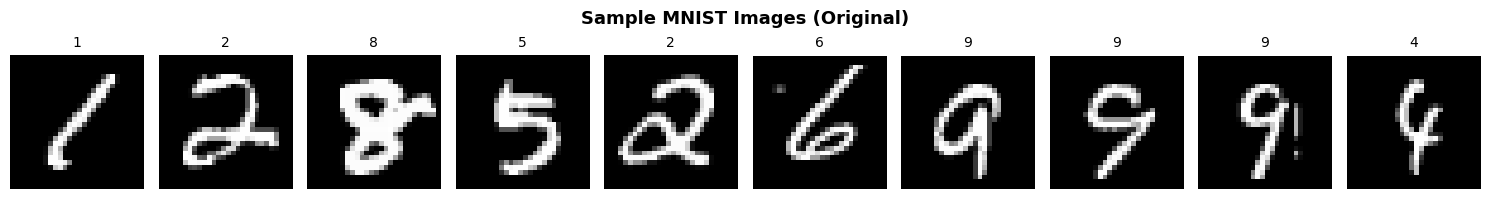

[Saved] mnist_samples.png


In [ ]:
def show_mnist_samples(loader, n=10):
    """Display sample MNIST digits before any processing."""
    imgs, labels = next(iter(loader))

    fig, axes = plt.subplots(1, n, figsize=(n*1.5, 2))
    fig.suptitle("Sample MNIST Images (Original)", fontsize=13, fontweight='bold')

    for i in range(n):
        axes[i].imshow(imgs[i].squeeze().numpy(), cmap='gray')
        # .squeeze() removes the channel dim: (1,28,28) → (28,28)
        axes[i].set_title(str(labels[i].item()), fontsize=10)
        axes[i].axis("off")

    plt.tight_layout()
    plt.savefig("mnist_samples.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("[Saved] mnist_samples.png")

show_mnist_samples(train_loader)

## Cell 4 — VAE Architecture

```
INPUT (784)
    │
    ▼  ENCODER
  Linear(784 → 512) → ReLU
  Linear(512 → 256) → ReLU
    │
    ├──► Linear(256 → 2)  →  μ        (mean vector)
    └──► Linear(256 → 2)  →  log(σ²)  (log variance vector)
    │
    ▼  REPARAMETERIZATION TRICK
  z = μ + σ × ε,   ε ~ N(0, I)
    │
    ▼  DECODER
  Linear(2   → 256) → ReLU
  Linear(256 → 512) → ReLU
  Linear(512 → 784) → Sigmoid
    │
    ▼
OUTPUT (784)
```

### Why Sigmoid at output?
Pixel values are in [0,1] after `ToTensor()`. Sigmoid ensures output matches this range.

### Why log σ² instead of σ²?
- Variance must be > 0, but log(σ²) can be any real number
- Unconstrained outputs are easier for networks to learn
- Recover σ² with: `σ² = exp(log_var)`

In [ ]:
class VAE(nn.Module):
    """
    Variational Autoencoder for MNIST.
    Encodes 784-dim input into a LATENT_DIM-dim Gaussian distribution,
    samples from it, then decodes back to 784-dim output.
    """

    def __init__(self, input_dim=784, hidden_dim=512, hidden_dim2=256, latent_dim=2):
        """
        input_dim  : size of flattened input (784 for MNIST 28x28)
        hidden_dim : first hidden layer size
        hidden_dim2: second hidden layer size
        latent_dim : size of latent space (2 for easy 2D visualization)
        """
        super(VAE, self).__init__()
        # super().__init__() initializes nn.Module — required for all PyTorch models

        self.latent_dim  = latent_dim
        self.input_dim   = input_dim

        # ── ENCODER LAYERS ───────────────────────────────────────────────────
        self.enc_fc1 = nn.Linear(input_dim,   hidden_dim)   # 784 → 512
        self.enc_fc2 = nn.Linear(hidden_dim,  hidden_dim2)  # 512 → 256

        # Two separate heads — one for μ, one for log(σ²)
        self.fc_mu      = nn.Linear(hidden_dim2, latent_dim)
        # Outputs the MEAN of the latent distribution

        self.fc_log_var = nn.Linear(hidden_dim2, latent_dim)
        # Outputs LOG VARIANCE — unconstrained, easier to learn
        # Recover variance: σ² = exp(log_var)

        # ── DECODER LAYERS ───────────────────────────────────────────────────
        self.dec_fc1 = nn.Linear(latent_dim,  hidden_dim2)  # 2   → 256
        self.dec_fc2 = nn.Linear(hidden_dim2, hidden_dim)   # 256 → 512
        self.dec_fc3 = nn.Linear(hidden_dim,  input_dim)    # 512 → 784

    def encode(self, x):
        """
        Encode input x into distribution parameters μ and log(σ²).
        x shape: (batch_size, 784)
        """
        h = F.relu(self.enc_fc1(x))   # (B, 512)
        h = F.relu(self.enc_fc2(h))   # (B, 256)
        mu      = self.fc_mu(h)       # (B, latent_dim) — no activation
        log_var = self.fc_log_var(h)  # (B, latent_dim) — no activation
        return mu, log_var

    def reparameterize(self, mu, log_var):
        """
        REPARAMETERIZATION TRICK:
        Instead of sampling z ~ N(μ, σ²) directly (not differentiable),
        we write: z = μ + σ × ε  where ε ~ N(0, 1)

        The randomness ε is OUTSIDE the computation graph.
        Gradients flow through μ and σ normally. ✓
        """
        if self.training:
            std     = torch.exp(0.5 * log_var)
            # log_var = log(σ²)  →  0.5 × log_var = log(σ)  →  exp = σ

            epsilon = torch.randn_like(std)
            # ε ~ N(0,1), same shape as std

            z = mu + std * epsilon
            # z = μ + σε  ≡ sample from N(μ, σ²)
            return z
        else:
            return mu   # During inference: use mean (deterministic)

    def decode(self, z):
        """
        Decode latent vector z back to image space.
        z shape: (batch_size, latent_dim)
        """
        h = F.relu(self.dec_fc1(z))             # (B, 256)
        h = F.relu(self.dec_fc2(h))             # (B, 512)
        x_reconstructed = torch.sigmoid(self.dec_fc3(h))
        # Sigmoid → output in [0,1] matching pixel range
        return x_reconstructed                   # (B, 784)

    def forward(self, x):
        """
        Complete VAE forward pass:
          1. Flatten input
          2. Encode → μ, log(σ²)
          3. Sample z via reparameterization
          4. Decode z → reconstructed image
        """
        x_flat          = x.view(x.size(0), -1)      # (B,1,28,28) → (B,784)
        mu, log_var     = self.encode(x_flat)         # (B,2), (B,2)
        z               = self.reparameterize(mu, log_var)  # (B,2)
        x_reconstructed = self.decode(z)              # (B,784)
        return x_reconstructed, mu, log_var


# ── Instantiate model ─────────────────────────────────────────────────────────
LATENT_DIM = 2
# Using 2D latent space so we can visualize it as a 2D scatter plot!

model = VAE(
    input_dim   = 784,
    hidden_dim  = 512,
    hidden_dim2 = 256,
    latent_dim  = LATENT_DIM
).to(DEVICE)

print("=== VAE Architecture ===")
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

=== VAE Architecture ===
VAE(
  (enc_fc1): Linear(in_features=784, out_features=512, bias=True)
  (enc_fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc_mu): Linear(in_features=256, out_features=2, bias=True)
  (fc_log_var): Linear(in_features=256, out_features=2, bias=True)
  (dec_fc1): Linear(in_features=2, out_features=256, bias=True)
  (dec_fc2): Linear(in_features=256, out_features=512, bias=True)
  (dec_fc3): Linear(in_features=512, out_features=784, bias=True)
)

Total trainable parameters: 1,068,820


## Cell 5 — Visualize Architecture Diagram

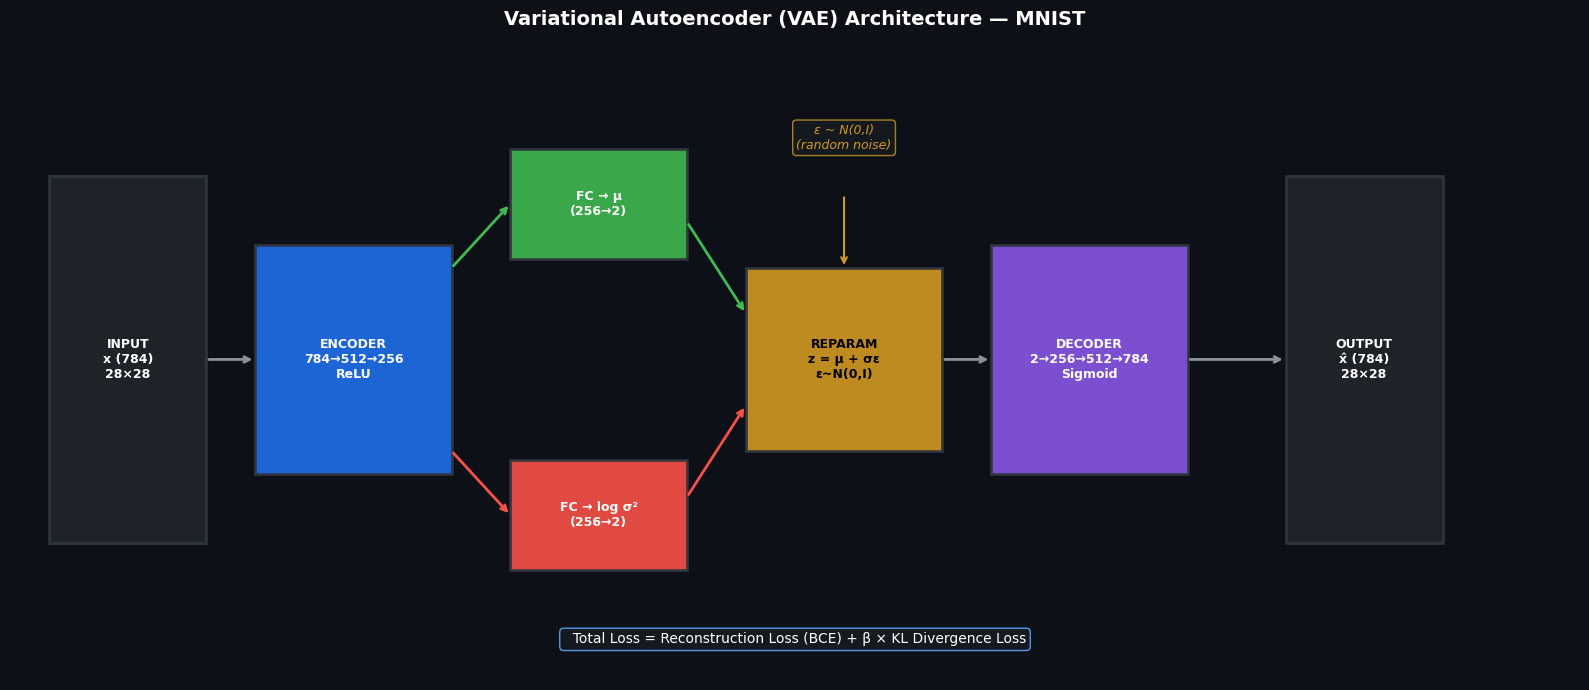

[Saved] vae_architecture.png


In [ ]:
def plot_vae_architecture():
    """Draw a clean block diagram of the VAE architecture."""
    fig = plt.figure(figsize=(16, 7), facecolor='#0d1117')
    ax  = fig.add_subplot(111)
    ax.set_facecolor('#0d1117')
    ax.set_xlim(0, 16); ax.set_ylim(0, 7); ax.axis('off')

    blocks = [
        (1.2,  3.5, 1.6, 4.0, "INPUT\nx (784)\n28×28",           '#21262d', 'white'),
        (3.5,  3.5, 2.0, 2.5, "ENCODER\n784→512→256\nReLU",      '#1f6feb', 'white'),
        (6.0,  5.2, 1.8, 1.2, "FC → μ\n(256→2)",                 '#3fb950', 'white'),
        (6.0,  1.8, 1.8, 1.2, "FC → log σ²\n(256→2)",            '#f85149', 'white'),
        (8.5,  3.5, 2.0, 2.0, "REPARAM\nz = μ + σε\nε~N(0,I)",  '#d29922', 'black'),
        (11.0, 3.5, 2.0, 2.5, "DECODER\n2→256→512→784\nSigmoid", '#8957e5', 'white'),
        (13.8, 3.5, 1.6, 4.0, "OUTPUT\nx̂ (784)\n28×28",          '#21262d', 'white'),
    ]

    for (xc, yc, w, h, text, fc, tc) in blocks:
        rect = plt.Rectangle((xc-w/2, yc-h/2), w, h,
                              facecolor=fc, edgecolor='#30363d',
                              linewidth=2, zorder=3, alpha=0.9)
        ax.add_patch(rect)
        ax.text(xc, yc, text, ha='center', va='center',
                color=tc, fontsize=9, fontweight='bold', zorder=4)

    arrow_props = dict(arrowstyle='->', color='#8b949e', lw=2)
    ax.annotate('', xy=(2.5,3.5), xytext=(2.0,3.5), arrowprops=arrow_props)
    ax.annotate('', xy=(5.1,5.2), xytext=(4.5,4.5), arrowprops=dict(arrowstyle='->', color='#3fb950', lw=2))
    ax.annotate('', xy=(5.1,1.8), xytext=(4.5,2.5), arrowprops=dict(arrowstyle='->', color='#f85149', lw=2))
    ax.annotate('', xy=(7.5,4.0), xytext=(6.9,5.0), arrowprops=dict(arrowstyle='->', color='#3fb950', lw=2))
    ax.annotate('', xy=(7.5,3.0), xytext=(6.9,2.0), arrowprops=dict(arrowstyle='->', color='#f85149', lw=2))
    ax.annotate('', xy=(10.0,3.5), xytext=(9.5,3.5), arrowprops=arrow_props)
    ax.annotate('', xy=(13.0,3.5), xytext=(12.0,3.5), arrowprops=arrow_props)

    ax.text(8.5, 5.8, 'ε ~ N(0,I)\n(random noise)', ha='center', fontsize=9,
            color='#d29922', style='italic',
            bbox=dict(boxstyle='round', facecolor='#161b22', edgecolor='#d29922', alpha=0.8))
    ax.annotate('', xy=(8.5,4.5), xytext=(8.5,5.3),
                arrowprops=dict(arrowstyle='->', color='#d29922', lw=1.5))

    ax.text(8.0, 0.4, '  Total Loss = Reconstruction Loss (BCE) + β × KL Divergence Loss',
            ha='center', fontsize=10, color='white',
            bbox=dict(boxstyle='round', facecolor='#161b22', edgecolor='#58a6ff', alpha=0.9))

    ax.set_title("Variational Autoencoder (VAE) Architecture — MNIST",
                 color='white', fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.savefig("vae_architecture.png", dpi=130, bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    print("[Saved] vae_architecture.png")

plot_vae_architecture()

## Cell 6 — Loss Function

### Reconstruction Loss (BCE)
$$\text{BCE}(\hat{x}, x) = -\sum_i \left[ x_i \log \hat{x}_i + (1-x_i) \log(1-\hat{x}_i) \right]$$

Each pixel is treated as a **Bernoulli random variable**. Lower BCE = better reconstruction.

### KL Divergence Loss
$$KL[N(\mu, \sigma^2) \| N(0,1)] = -\frac{1}{2} \sum_j \left(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

This closed-form solution forces the latent distribution toward N(0,1):
- `μ → 0` (penalizes mean away from zero)
- `σ² → 1` (penalizes variance too far from 1)

KL = 0 **only when** μ=0 and σ²=1 (perfect standard normal)

In [ ]:
def vae_loss(x_reconstructed, x_original, mu, log_var, beta=1.0):
    """
    VAE Loss = Reconstruction Loss + β × KL Divergence Loss

    Parameters:
      x_reconstructed : (batch_size, 784) decoder output
      x_original      : (batch_size, 1, 28, 28) input images
      mu              : (batch_size, latent_dim) mean from encoder
      log_var         : (batch_size, latent_dim) log variance from encoder
      beta            : weight on KL divergence (beta=1 → standard VAE)

    Returns: total_loss (tensor), recon_loss (float), kl_loss (float)
    """
    batch_size = x_original.size(0)
    x_flat     = x_original.view(batch_size, -1)   # (B, 784)

    # ── Reconstruction Loss (Binary Cross Entropy) ────────────────────────────
    recon_loss = F.binary_cross_entropy(
        x_reconstructed,   # Predicted pixel values [0,1]
        x_flat,            # True pixel values [0,1]
        reduction='sum'    # Sum over all pixels AND batch samples
    ) / batch_size
    # Per-sample average. Good MNIST VAE: ~80-120

    # ── KL Divergence Loss ────────────────────────────────────────────────────
    # Closed-form for KL[N(μ,σ²) || N(0,1)]:
    kl_loss = -0.5 * torch.sum(
        1 + log_var           # log(σ²)
          - mu.pow(2)         # μ²  (penalizes mean away from 0)
          - log_var.exp()     # σ² = exp(log(σ²))
    ) / batch_size
    # Always ≥ 0. Equals 0 only when μ=0, σ²=1

    # ── Total Loss ────────────────────────────────────────────────────────────
    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss.item(), kl_loss.item()

print("Loss function defined.")
print("Formula: Total = BCE(x̂, x) + β × KL[N(μ,σ²) || N(0,1)]")
print("β = 1.0 (standard VAE)")

Loss function defined.
Formula: Total = BCE(x̂, x) + β × KL[N(μ,σ²) || N(0,1)]
β = 1.0 (standard VAE)


## Cell 7 — Training Loop

### What happens each epoch:
1. **Forward pass** → get x̂, μ, log σ²
2. **Compute loss** → BCE + β·KL
3. **Backward pass** → `loss.backward()` computes gradients via backpropagation
4. **Gradient clipping** → prevents exploding gradients (NaN)
5. **Optimizer step** → update weights: `w = w - lr × ∂L/∂w`
6. **Validation** → evaluate on test set with `torch.no_grad()`

In [ ]:
EPOCHS   = 30
LR       = 1e-3
BETA     = 1.0   # Standard VAE

optimizer = optim.Adam(
    model.parameters(),
    lr           = LR,
    weight_decay = 1e-5
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

history = {
    'train_total': [], 'val_total': [],
    'train_recon': [], 'val_recon': [],
    'train_kl':    [], 'val_kl':    []
}

best_val_loss = float('inf')

print("="*75)
print(f"{'Epoch':>5} | {'Train Total':>11} | {'Train Recon':>11} | {'Train KL':>9} | {'Val Total':>9} | {'Val Recon':>9}")
print("="*75)

for epoch in range(1, EPOCHS + 1):

    # ── TRAINING ─────────────────────────────────────────────────────────────
    model.train()
    # model.train() enables reparameterization (sample ε) and dropout

    epoch_total = epoch_recon = epoch_kl = 0.0
    n_batches = 0

    for imgs, _ in train_loader:
        imgs = imgs.to(DEVICE)

        # Forward pass
        x_reconstructed, mu, log_var = model(imgs)

        # Compute loss
        total_loss, recon_loss, kl_loss = vae_loss(
            x_reconstructed, imgs, mu, log_var, beta=BETA
        )

        # Backward pass
        optimizer.zero_grad()       # Clear old gradients
        total_loss.backward()       # Compute ∂Loss/∂weights via backprop
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        # Gradient clipping: prevents exploding gradients
        optimizer.step()            # Update: w = w - lr × gradient

        epoch_total += total_loss.item()
        epoch_recon += recon_loss
        epoch_kl    += kl_loss
        n_batches   += 1

    tr_total = epoch_total / n_batches
    tr_recon = epoch_recon / n_batches
    tr_kl    = epoch_kl    / n_batches

    # ── VALIDATION ───────────────────────────────────────────────────────────
    model.eval()
    # model.eval() uses z = μ (deterministic, no ε sampling)

    val_total = val_recon = val_kl = 0.0
    val_batches = 0

    with torch.no_grad():
        # Disable gradient tracking — saves memory during evaluation
        for imgs, _ in test_loader:
            imgs = imgs.to(DEVICE)
            x_reconstructed, mu, log_var = model(imgs)
            t, r, k = vae_loss(x_reconstructed, imgs, mu, log_var, beta=BETA)
            val_total   += t.item()
            val_recon   += r
            val_kl      += k
            val_batches += 1

    vl_total = val_total   / val_batches
    vl_recon = val_recon   / val_batches

    scheduler.step(vl_total)

    history['train_total'].append(tr_total)
    history['val_total'].append(vl_total)
    history['train_recon'].append(tr_recon)
    history['val_recon'].append(vl_recon)
    history['train_kl'].append(tr_kl)
    history['val_kl'].append(val_kl / val_batches)

    if vl_total < best_val_loss:
        best_val_loss = vl_total
        torch.save(model.state_dict(), "best_vae.pth")

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>5} | {tr_total:>11.2f} | {tr_recon:>11.2f} | {tr_kl:>9.2f} | {vl_total:>9.2f} | {vl_recon:>9.2f}")

print("="*75)
print(f"Best Validation Loss: {best_val_loss:.2f}")
print("[Saved] best_vae.pth")

Epoch | Train Total | Train Recon |  Train KL | Val Total | Val Recon


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


    1 |      181.83 |      177.75 |      4.08 |    163.21 |    158.05
    5 |      149.80 |      143.82 |      5.97 |    147.58 |    141.64
   10 |      144.55 |      138.27 |      6.29 |    143.91 |    137.52
   15 |      142.24 |      135.79 |      6.45 |    141.86 |    135.16
   20 |      140.88 |      134.31 |      6.57 |    140.19 |    133.67
   25 |      139.82 |      133.17 |      6.65 |    139.95 |    133.31
   30 |      139.14 |      132.43 |      6.71 |    139.72 |    132.97
Best Validation Loss: 139.24
[Saved] best_vae.pth


## Cell 8 — Training Curves

**Expected behaviour:**
- **Reconstruction loss**: steadily decreases as model learns digit structure
- **KL loss**: starts near 0, gradually increases then stabilizes (model balancing both objectives)
- **Total loss**: decreases overall with minor fluctuations

Loaded best model weights.


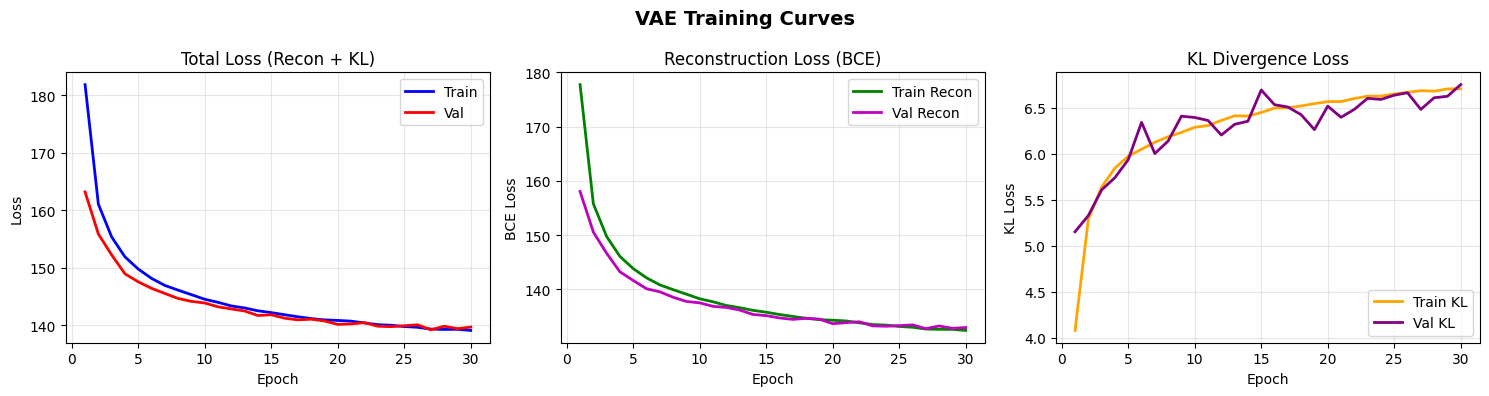

[Saved] vae_training_curves.png


In [ ]:
# Load best weights
model.load_state_dict(torch.load("best_vae.pth", map_location=DEVICE, weights_only=False))
print("Loaded best model weights.")

def plot_training_curves(history):
    epochs = range(1, len(history['train_total']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("VAE Training Curves", fontsize=14, fontweight='bold')

    # Total Loss
    axes[0].plot(epochs, history['train_total'], 'b-', lw=2, label='Train')
    axes[0].plot(epochs, history['val_total'],   'r-', lw=2, label='Val')
    axes[0].set_title("Total Loss (Recon + KL)")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Reconstruction Loss
    axes[1].plot(epochs, history['train_recon'], 'g-', lw=2, label='Train Recon')
    axes[1].plot(epochs, history['val_recon'],   'm-', lw=2, label='Val Recon')
    axes[1].set_title("Reconstruction Loss (BCE)")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("BCE Loss")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    # KL Divergence
    axes[2].plot(epochs, history['train_kl'], 'orange', lw=2, label='Train KL')
    axes[2].plot(epochs, history['val_kl'],   'purple', lw=2, label='Val KL')
    axes[2].set_title("KL Divergence Loss")
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("KL Loss")
    axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("vae_training_curves.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("[Saved] vae_training_curves.png")

plot_training_curves(history)

## Cell 9 — Original vs Reconstructed Images

Three rows:
1. **Original** — ground truth test images
2. **Reconstructed** — VAE output
3. **Error Map** — per-pixel absolute error (hot colormap: dark=accurate, bright=error)

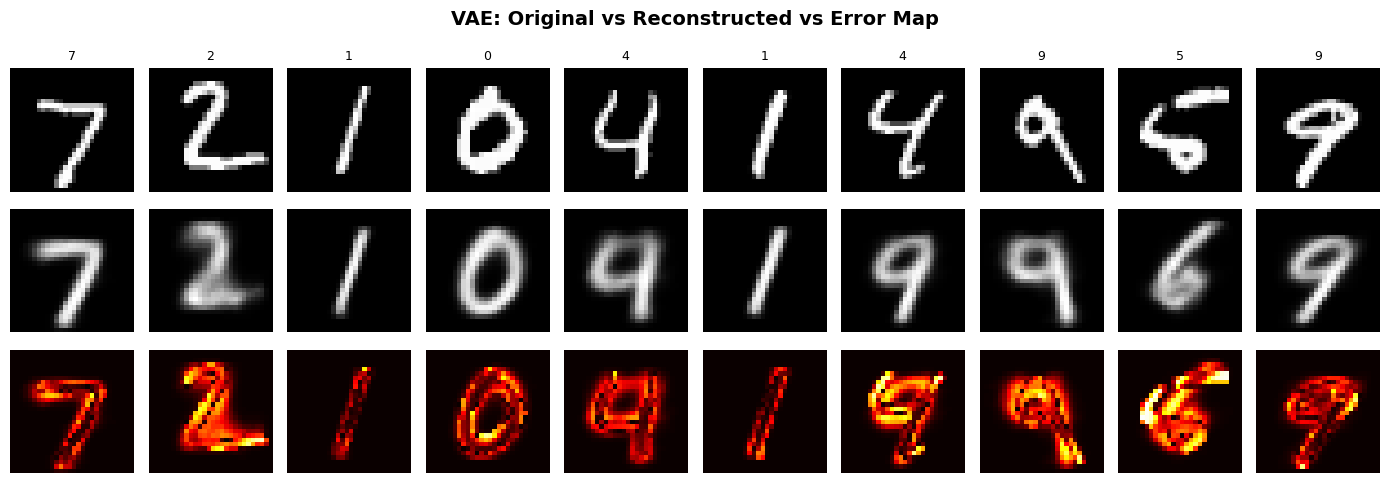

[Saved] vae_reconstructions.png
Row 3 (Error Map): Dark = accurate | Bright/hot = high pixel error


In [ ]:
def visualize_reconstructions(model, loader, n=10):
    model.eval()
    imgs, labels = next(iter(loader))
    imgs = imgs[:n].to(DEVICE)

    with torch.no_grad():
        x_recon, mu, log_var = model(imgs)

    x_recon = x_recon.view(n, 1, 28, 28)

    fig, axes = plt.subplots(3, n, figsize=(n*1.4, 5))
    fig.suptitle("VAE: Original vs Reconstructed vs Error Map",
                 fontsize=14, fontweight='bold')

    for i in range(n):
        # Row 1: Original
        axes[0, i].imshow(imgs[i].cpu().squeeze(), cmap='gray')
        axes[0, i].set_title(str(labels[i].item()), fontsize=9)
        axes[0, i].axis("off")

        # Row 2: Reconstructed
        axes[1, i].imshow(x_recon[i].cpu().squeeze(), cmap='gray')
        axes[1, i].axis("off")

        # Row 3: Absolute difference per pixel
        diff = (imgs[i].cpu() - x_recon[i].cpu()).abs().squeeze()
        axes[2, i].imshow(diff, cmap='hot', vmin=0, vmax=1)
        # hot colormap: dark=small error, bright=large error
        axes[2, i].axis("off")

    axes[0, 0].set_ylabel("Original",  fontsize=10, rotation=0, labelpad=45)
    axes[1, 0].set_ylabel("Recon",     fontsize=10, rotation=0, labelpad=38)
    axes[2, 0].set_ylabel("Error Map", fontsize=10, rotation=0, labelpad=45)

    plt.tight_layout()
    plt.savefig("vae_reconstructions.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("[Saved] vae_reconstructions.png")
    print("Row 3 (Error Map): Dark = accurate | Bright/hot = high pixel error")

visualize_reconstructions(model, test_loader)

## Cell 10 — Generate New Images by Sampling

**Key VAE advantage over regular autoencoders:**
We can generate *brand new digits* by sampling `z ~ N(0,1)` directly, without any input image.

This works because **KL loss** trained the encoder to organize the latent space like N(0,1),
so random samples from N(0,1) decode into valid-looking digits.

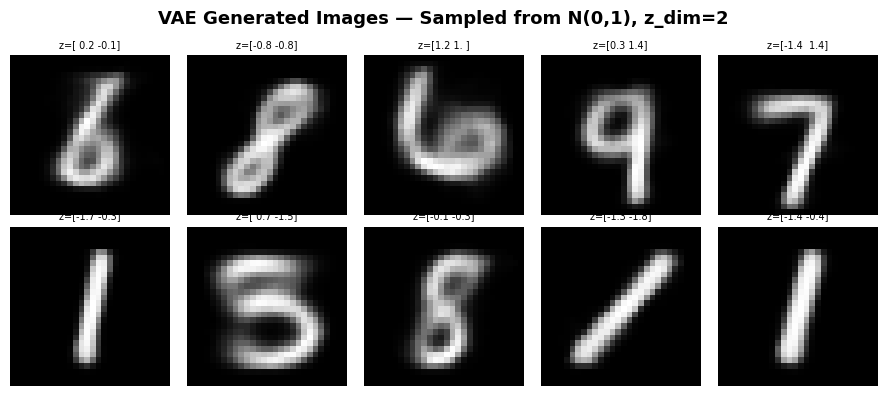

[Saved] vae_generated.png
These are BRAND NEW digits — never seen during training!


In [ ]:
def generate_images(model, n=10):
    """Generate brand new digits by sampling from N(0,1)."""
    model.eval()

    with torch.no_grad():
        z = torch.randn(n, model.latent_dim).to(DEVICE)
        # Sample n random points from N(0,1)
        # KL loss ensured this region maps to valid digits

        generated = model.decode(z)
        # Decode directly — no encoder needed for generation!

    generated = generated.view(n, 1, 28, 28).cpu()

    fig, axes = plt.subplots(2, n//2, figsize=(n*0.9, 4))
    fig.suptitle(f"VAE Generated Images — Sampled from N(0,1), z_dim={model.latent_dim}",
                 fontsize=13, fontweight='bold')

    for i, ax in enumerate(axes.flat):
        ax.imshow(generated[i].squeeze(), cmap='gray')
        ax.axis("off")
        ax.set_title(f"z={z[i].cpu().numpy().round(1)}", fontsize=7)

    plt.tight_layout()
    plt.savefig("vae_generated.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("[Saved] vae_generated.png")
    print("These are BRAND NEW digits — never seen during training!")

generate_images(model, n=10)

## Cell 11 — 2D Latent Space Visualization

Since `LATENT_DIM=2`, we can plot the entire latent space as a 2D scatter plot.

**Expected observations for a well-trained VAE:**
- Different digit classes form **distinct clusters**
- Clusters **overlap smoothly** (continuous latent space — unlike regular AE)
- Everything **centered around (0,0)** with spread ~1 (due to KL regularization)

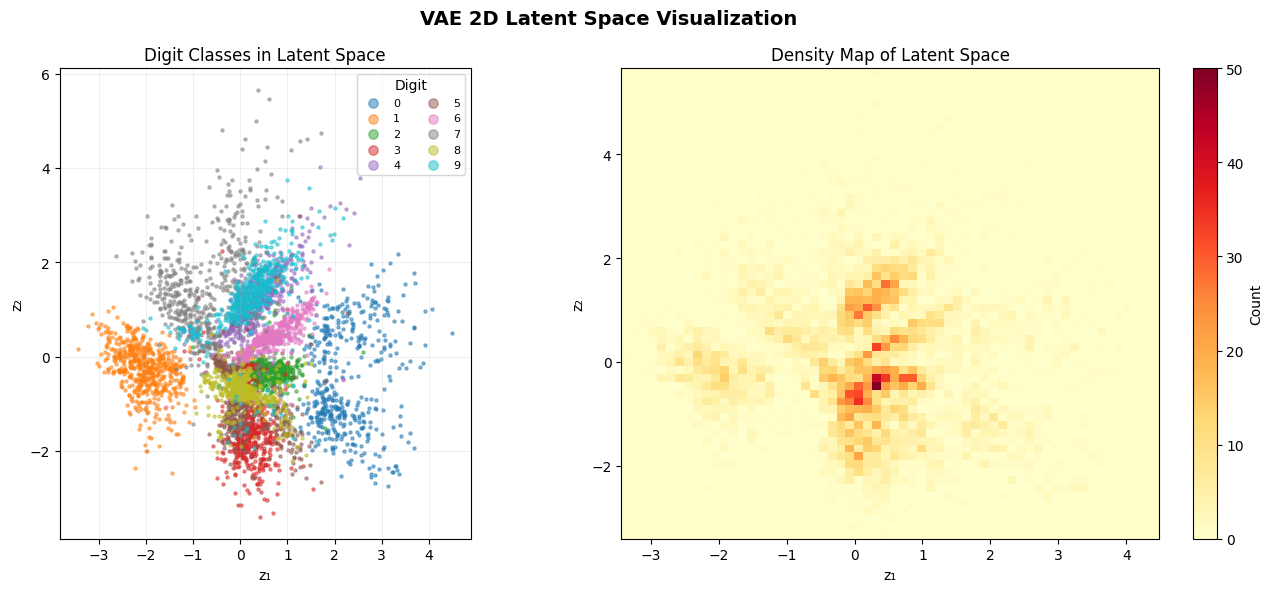

[Saved] vae_latent_space.png
Good VAE: clusters are distinct but adjacent (smooth transitions)
Distribution should be roughly circular, centered at (0,0)


In [ ]:
def visualize_latent_space(model, loader, n_samples=5000):
    """Plot where MNIST digits live in 2D latent space, colored by class."""
    model.eval()
    all_mu = []; all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            mu, _ = model.encode(imgs.view(imgs.size(0), -1))
            # Use μ (mean) for plotting — most representative latent point
            all_mu.append(mu.cpu().numpy())
            all_labels.append(labels.numpy())
            if sum(len(m) for m in all_mu) >= n_samples:
                break

    all_mu     = np.concatenate(all_mu)[:n_samples]      # (n_samples, 2)
    all_labels = np.concatenate(all_labels)[:n_samples]  # (n_samples,)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("VAE 2D Latent Space Visualization", fontsize=14, fontweight='bold')

    # Scatter plot — each color = one digit class
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    for digit in range(10):
        mask = all_labels == digit
        axes[0].scatter(all_mu[mask, 0], all_mu[mask, 1],
                        c=[colors[digit]], label=str(digit),
                        alpha=0.5, s=5)
    axes[0].set_title("Digit Classes in Latent Space")
    axes[0].set_xlabel("z₁"); axes[0].set_ylabel("z₂")
    axes[0].legend(title="Digit", markerscale=3, ncol=2, fontsize=8)
    axes[0].grid(True, alpha=0.2); axes[0].set_aspect('equal')

    # Density heatmap
    h = axes[1].hist2d(all_mu[:,0], all_mu[:,1], bins=60, cmap='YlOrRd')
    plt.colorbar(h[3], ax=axes[1], label='Count')
    axes[1].set_title("Density Map of Latent Space")
    axes[1].set_xlabel("z₁"); axes[1].set_ylabel("z₂")

    plt.tight_layout()
    plt.savefig("vae_latent_space.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("[Saved] vae_latent_space.png")
    print("Good VAE: clusters are distinct but adjacent (smooth transitions)")
    print("Distribution should be roughly circular, centered at (0,0)")

visualize_latent_space(model, test_loader)

## Cell 12 — Latent Space Manifold (20×20 Grid)

Systematically traverse the 2D latent space on a regular grid and decode each point.

- Each cell = one generated image from that z position
- **Smooth transitions** between cells = well-organized latent space
- You should see digits **gradually morphing** into each other

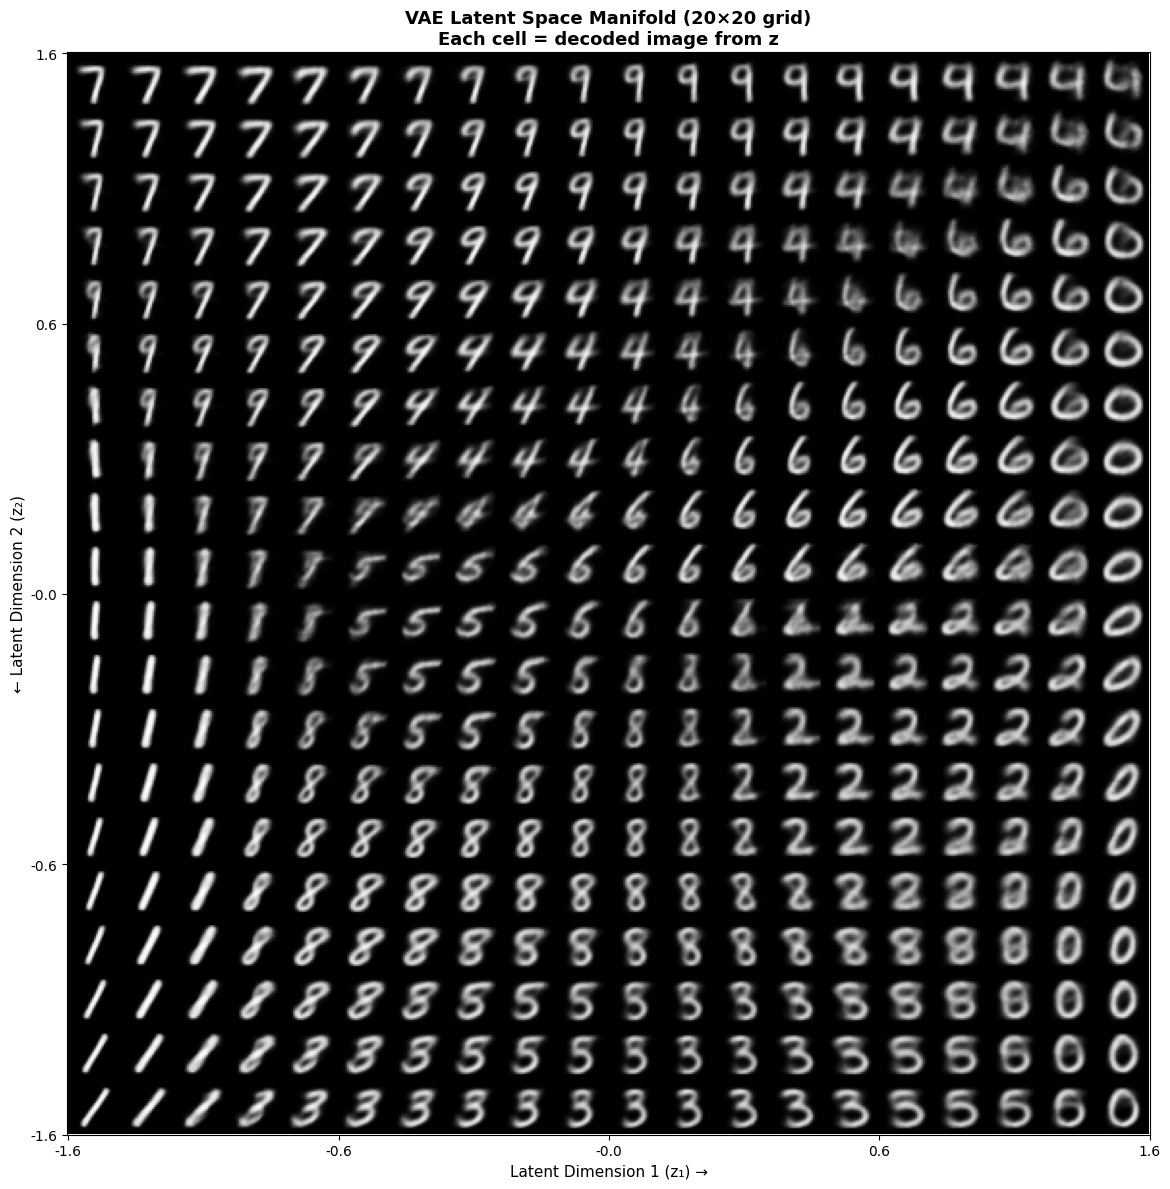

[Saved] vae_manifold.png


In [ ]:
def visualize_latent_manifold(model, n=20):
    """
    Traverse the 2D latent space on a regular grid.
    Each grid point → decode → one image.
    Visualizes what each region of latent space 'means' to the model.
    """
    model.eval()

    # norm.ppf: inverse CDF maps uniform [0.05,0.95] → z-scores
    # Gives better coverage than linear spacing
    grid_x = norm.ppf(np.linspace(0.05, 0.95, n))
    grid_y = norm.ppf(np.linspace(0.05, 0.95, n))

    canvas = np.zeros((n * 28, n * 28))

    with torch.no_grad():
        for i, yi in enumerate(grid_y[::-1]):   # Flip y so top=high value
            for j, xi in enumerate(grid_x):
                z = torch.tensor([[xi, yi]], dtype=torch.float32).to(DEVICE)
                decoded = model.decode(z).cpu().view(28, 28).numpy()
                canvas[i*28:(i+1)*28, j*28:(j+1)*28] = decoded

    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(canvas, cmap='gray', origin='upper')
    ax.set_title(f"VAE Latent Space Manifold ({n}×{n} grid)\nEach cell = decoded image from z",
                 fontsize=13, fontweight='bold')
    ax.set_xlabel("Latent Dimension 1 (z₁) →", fontsize=11)
    ax.set_ylabel("← Latent Dimension 2 (z₂)", fontsize=11)

    tick_pos = np.linspace(0, n*28, 5)
    tick_val = np.round(norm.ppf(np.linspace(0.05, 0.95, 5)), 1)
    ax.set_xticks(tick_pos); ax.set_xticklabels(tick_val)
    ax.set_yticks(tick_pos); ax.set_yticklabels(tick_val[::-1])

    plt.tight_layout()
    plt.savefig("vae_manifold.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("[Saved] vae_manifold.png")

visualize_latent_manifold(model, n=20)

## Cell 13 — Digit Interpolation

Encode two real digits, **linearly interpolate** between their latent codes, decode each step.

$$z(t) = (1-t) \cdot \mu_A + t \cdot \mu_B, \quad t \in [0, 1]$$

- t=0 → pure digit A
- t=0.5 → halfway between A and B
- t=1 → pure digit B

**Smooth morphing = well-structured VAE latent space.** A regular autoencoder would produce noise in the middle!

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


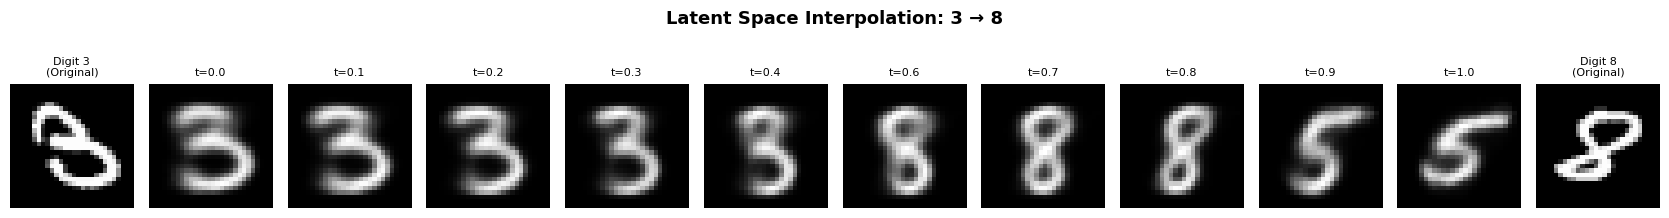

[Saved] vae_interpolation_3to8.png


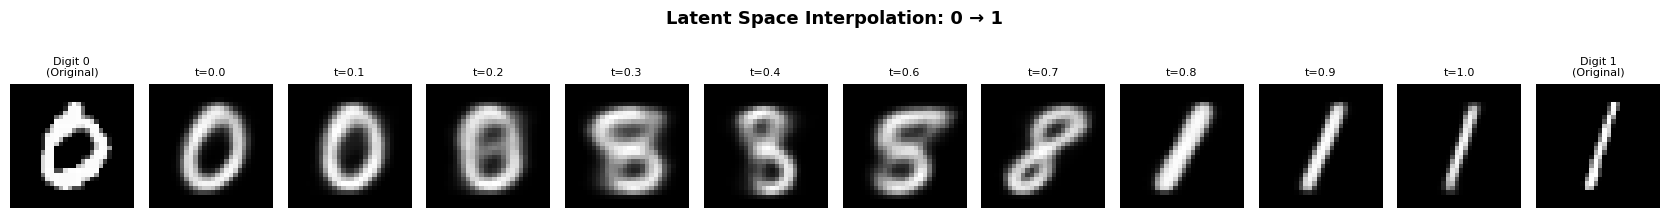

[Saved] vae_interpolation_0to1.png


In [ ]:
def interpolate_between_digits(model, loader, digit_a=3, digit_b=8, steps=10):
    """Linearly interpolate between two digits in latent space."""
    model.eval()

    # Find one example of each digit
    img_a = img_b = None
    for imgs, labels in loader:
        for img, label in zip(imgs, labels):
            if img_a is None and label.item() == digit_a: img_a = img
            if img_b is None and label.item() == digit_b: img_b = img
            if img_a is not None and img_b is not None: break
        if img_a is not None and img_b is not None: break

    with torch.no_grad():
        mu_a, _ = model.encode(img_a.unsqueeze(0).to(DEVICE).view(1,-1))
        mu_b, _ = model.encode(img_b.unsqueeze(0).to(DEVICE).view(1,-1))

        interpolated = []
        for t in np.linspace(0, 1, steps):
            z_interp = (1-t) * mu_a + t * mu_b
            # Linear interpolation: at t=0 → μ_a, at t=1 → μ_b
            decoded = model.decode(z_interp)
            interpolated.append(decoded.cpu().view(28,28))

    fig, axes = plt.subplots(1, steps+2, figsize=((steps+2)*1.4, 2.5))
    fig.suptitle(f"Latent Space Interpolation: {digit_a} → {digit_b}",
                 fontsize=13, fontweight='bold')

    axes[0].imshow(img_a.squeeze(), cmap='gray')
    axes[0].set_title(f"Digit {digit_a}\n(Original)", fontsize=8)
    axes[0].axis("off")

    for i, img in enumerate(interpolated):
        axes[i+1].imshow(img.numpy(), cmap='gray')
        axes[i+1].set_title(f"t={i/(steps-1):.1f}", fontsize=8)
        axes[i+1].axis("off")

    axes[-1].imshow(img_b.squeeze(), cmap='gray')
    axes[-1].set_title(f"Digit {digit_b}\n(Original)", fontsize=8)
    axes[-1].axis("off")

    plt.tight_layout()
    plt.savefig(f"vae_interpolation_{digit_a}to{digit_b}.png", dpi=120, bbox_inches='tight')
    plt.show()
    print(f"[Saved] vae_interpolation_{digit_a}to{digit_b}.png")

interpolate_between_digits(model, test_loader, digit_a=3, digit_b=8, steps=10)
interpolate_between_digits(model, test_loader, digit_a=0, digit_b=1, steps=10)

## Cell 14 — Final Evaluation & Summary

In [ ]:
def print_final_summary(model, loader, history):
    model.eval()
    total_losses=[]; recon_losses=[]; kl_losses=[]

    with torch.no_grad():
        for imgs, _ in loader:
            imgs = imgs.to(DEVICE)
            x_recon, mu, log_var = model(imgs)
            t, r, k = vae_loss(x_recon, imgs, mu, log_var, beta=BETA)
            total_losses.append(t.item())
            recon_losses.append(r)
            kl_losses.append(k)

    avg_total = np.mean(total_losses)
    avg_recon = np.mean(recon_losses)
    avg_kl    = np.mean(kl_losses)

    print("="*60)
    print("  VARIATIONAL AUTOENCODER — FINAL RESULTS")
    print("="*60)
    print(f"  Dataset      : MNIST (28×28 grayscale, 10 classes)")
    print(f"  Architecture : 784→512→256→{LATENT_DIM}→256→512→784")
    print(f"  Latent Dim   : {LATENT_DIM} (2D for visualization)")
    print(f"  Epochs       : {EPOCHS}  |  LR: {LR}  |  β: {BETA}")
    print()
    print(f"  ┌────────────────────────────────┐")
    print(f"  │ Test Reconstruction Loss : {avg_recon:6.2f} │")
    print(f"  │ Test KL Divergence Loss  : {avg_kl:6.2f} │")
    print(f"  │ Test Total Loss          : {avg_total:6.2f} │")
    print(f"  └────────────────────────────────┘")
    print(f"  Interpretation:")
    print(f"  Reconstruction Loss ({avg_recon:.1f}):")
    print(f"    Pixel accuracy. Lower = sharper. Good 2D VAE: 80-120.")
    print(f"  KL Divergence Loss ({avg_kl:.1f}):")
    print(f"    Latent organization. 0 only when mu=0, sigma=1.")
    print(f"  Total Loss ({avg_total:.1f}) = {avg_recon:.1f} + {BETA} x {avg_kl:.1f}")
    print()
    print("  Output Files:")
    print("    mnist_samples.png           - Raw dataset samples")
    print("    vae_architecture.png        - Architecture block diagram")
    print("    vae_training_curves.png     - Loss curves (Total, Recon, KL)")
    print("    vae_reconstructions.png     - Original vs Reconstructed + Error Map")
    print("    vae_generated.png           - New digits from N(0,1) sampling")
    print("    vae_latent_space.png        - 2D scatter + density plot")
    print("    vae_manifold.png            - 20x20 latent space grid")
    print("    vae_interpolation_3to8.png  - Smooth morphing 3 to 8")
    print("    vae_interpolation_0to1.png  - Smooth morphing 0 to 1")
    print("    best_vae.pth                - Saved model weights")

print_final_summary(model, test_loader, history)

  VARIATIONAL AUTOENCODER — FINAL RESULTS
  Dataset      : MNIST (28×28 grayscale, 10 classes)
  Architecture : 784→512→256→2→256→512→784
  Latent Dim   : 2 (2D for visualization)
  Epochs       : 30  |  LR: 0.001  |  β: 1.0

  ┌────────────────────────────────┐
  │ Test Reconstruction Loss : 132.76 │
  │ Test KL Divergence Loss  :   6.48 │
  │ Test Total Loss          : 139.24 │
  └────────────────────────────────┘
  Interpretation:
  Reconstruction Loss (132.8):
    Pixel accuracy. Lower = sharper. Good 2D VAE: 80-120.
  KL Divergence Loss (6.5):
    Latent organization. 0 only when mu=0, sigma=1.
  Total Loss (139.2) = 132.8 + 1.0 x 6.5

  Output Files:
    mnist_samples.png           - Raw dataset samples
    vae_architecture.png        - Architecture block diagram
    vae_training_curves.png     - Loss curves (Total, Recon, KL)
    vae_reconstructions.png     - Original vs Reconstructed + Error Map
    vae_generated.png           - New digits from N(0,1) sampling
    vae_latent_sp